# Imports

In [3]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

PosixPath('/home/manuel/projects/repos/mestrado/pdi')

# Methods

In [67]:
def load_image(image_path):
    image = Image.open(image_path).convert('L')  # Converte para escala de cinza
    return np.array(image)

def apply_fourier_transform(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)  # Centraliza as baixas frequências
    magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)  # Evita log(0)
    return magnitude_spectrum

def plot_images(dict_content: dict[str], figsize: tuple[int, int] = (12, 6)) -> tuple[plt.Figure, np.ndarray]:
    fig, ax = plt.subplots(len(dict_content), 2, figsize=figsize)

    # Ensure ax is always a 2D array
    if len(dict_content) == 1:
        ax = np.expand_dims(ax, axis=0)

    # Imagem original
    for idx, (key, value) in enumerate(dict_content.items()):
        ax[idx, 0].set_title("Imagem Original")
        ax[idx, 0].imshow(value["original"]["img"], **value["original"]["args"])
        ax[idx, 0].axis('off')

        ax[idx, 1].set_title("Transformada")
        ax[idx, 1].imshow(value["transformada"]["img"], **value["transformada"]["args"])
        ax[idx, 1].axis('off')

    fig.tight_layout()
    plt.show()
    return fig, ax

# Parameters

In [46]:
path_assets = PROJECT_DIR / 'assets'

# Questão 01

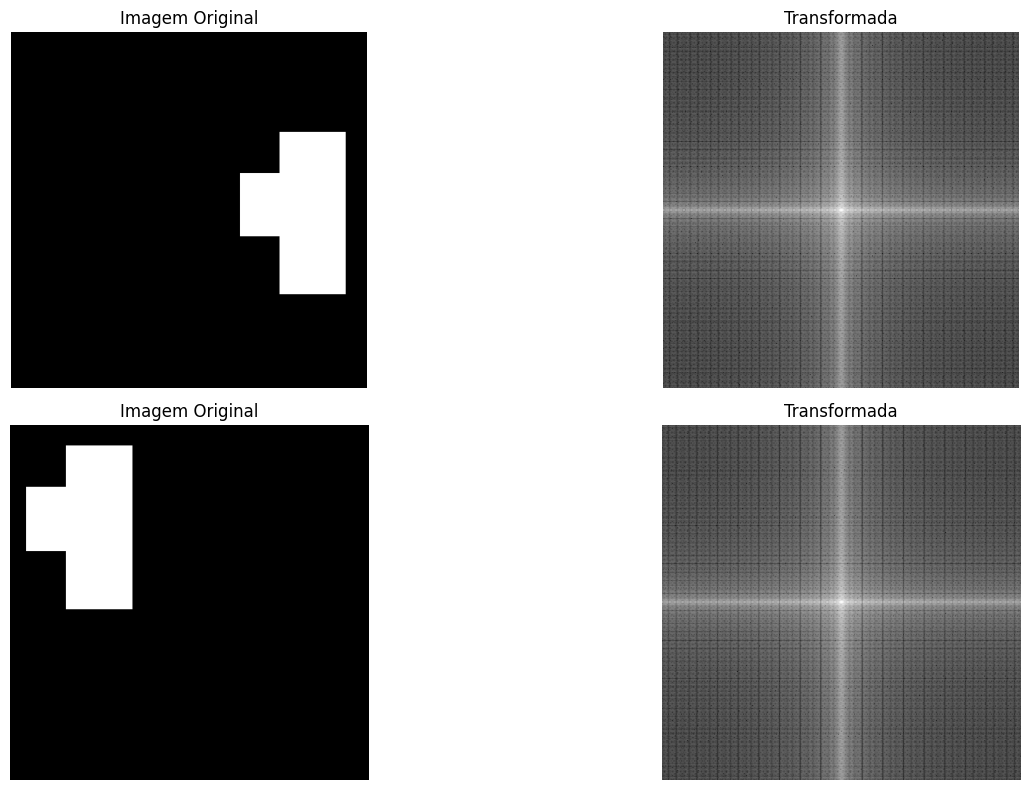

In [49]:


q1_i1 = load_image(path_assets / "atv02-q01-03.png")
q1_i2 = load_image(path_assets / "atv02-q01-04.png")

i1_magnitude_spectrum = apply_fourier_transform(q1_i1)
i2_magnitude_spectrum = apply_fourier_transform(q1_i2)

fig_q1_i1, ax_q1_i1 = plot_images(
    {
        "img_1": {
            "original": {
                "img": q1_i1,
                "args": {"cmap": 'gray'}
            },
            "transformada": {
                "img": i1_magnitude_spectrum,
                "args": {"cmap": 'gray'}
            }
        },
        "img_2": {
            "original": {
                "img": q1_i2,
                "args": {"cmap": 'gray'}
            },
            "transformada": {
                "img": i2_magnitude_spectrum,
                "args": {"cmap": 'gray'}
            }
        }
    },
    figsize=(16, 8)
)
fig_q1_i1.savefig(path_assets / "atv02-q01-05.png", dpi=400, bbox_inches='tight')


# Questão 02

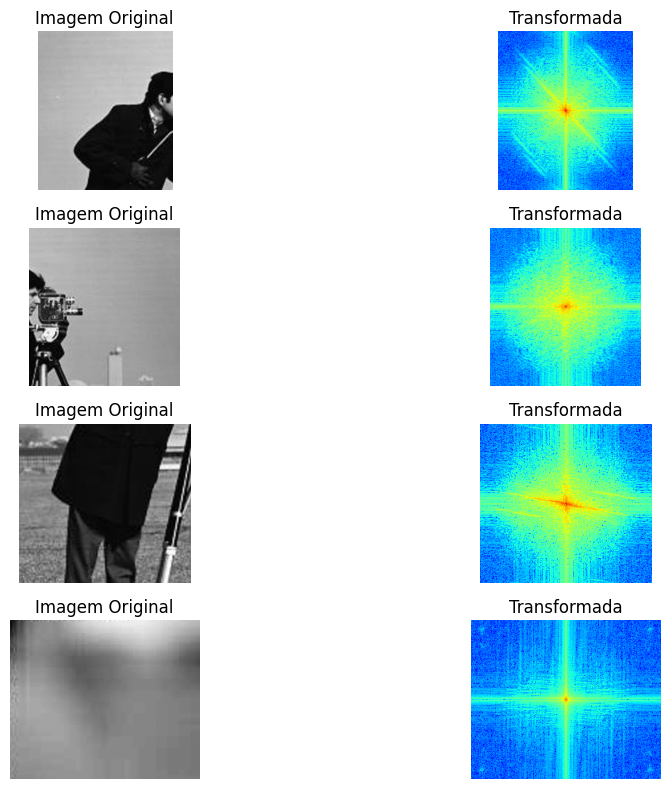

In [ ]:
q2_imgs = {
    f"q0{k}": load_image(path_assets / f"atv02-q02-0{k}.png") for k in range(3, 7)
}

transformadas = {
    key: apply_fourier_transform(value) for key, value in q2_imgs.items()
}

fig_q2_i1, ax_q2_i1 = plot_images(
    {
        key: {
            "original": {
                "img": q2_imgs[key],
                "args": {"cmap": 'gray'}
            },
            "transformada": {
                "img": value,
                "args": {"cmap": 'jet'}
            }
        }
        for key, value in transformadas.items()
    },
    figsize=(12, 8)
)
fig_q2_i1.savefig(path_assets / "atv02-q02-07.png", dpi=400, bbox_inches='tight')
